In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1,1],[1,2],[2,2],[2,3]])

# y = 1* x_0 + 2*x_1 +3
y = np.dot(X,np.array([1,2]))+3

reg = LinearRegression().fit(X,y)
reg.score(X,y)

1.0

In [2]:
reg.coef_

array([1., 2.])

In [3]:
reg.intercept_

np.float64(3.0000000000000018)

In [5]:
reg.predict(np.array([[3,5]]))

array([16.])

In [1]:
# Example of simple linear regression

Coefficient: [4.17142857]
Intercept: 46.4


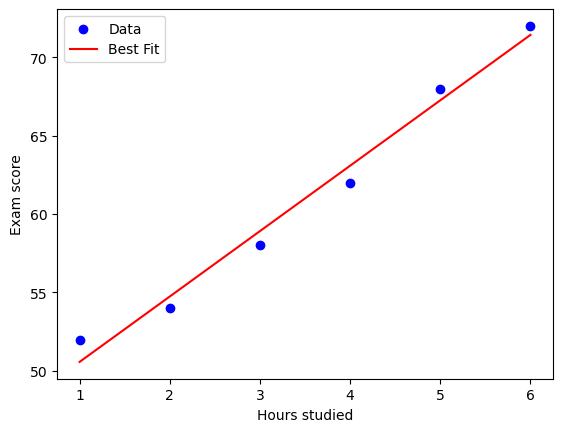

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data: hours studied vs exam score
X = np.array([1,2,3,4,5,6]).reshape(-1,1) # predictor
y = np.array([52, 54, 58, 62, 68, 72]) # target

# Fit Model
model = LinearRegression()
model.fit(X,y)

# Prediction
y_pred = model.predict(X)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

#Plot
plt.scatter(X,y, color='blue', label = "Data")
plt.plot(X,y_pred, color ="red", label = "Best Fit")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.legend()
plt.show()

In [ ]:
# Multiple Linear Regression (several predictors)

In [3]:
import pandas as pd

# Fake dataset: house price based on size and number of bedrooms
data = pd.DataFrame({
    "size": [1000, 1500, 2000, 2500, 3000],
    "bedrooms": [2,3,3,4,4],
    "price": [200000, 250000, 280000,310000, 360000]
})

X = data[["size", "bedrooms"]] # predictors
y = data["price"] # target

model = LinearRegression()
model.fit(X,y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 7.60000000e+01 -9.96301962e-12]
Intercept: 127999.99999999997


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()), # normalize predictors
    ("model", LinearRegression())
])

pipe.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [6]:
coef_scaled = pipe.named_steps["model"].coef_
intercept_scaled = pipe.named_steps["model"].intercept_

import numpy as np

scaler = pipe.named_steps["scaler"]
linreg = pipe.named_steps["model"]

# Scale parameters
means = scaler.mean_
scales = scaler.scale_

# Rescale coefficients
coef_original = linreg.coef_ / scales
intercept_original = linreg.intercept_ - np.sum((linreg.coef_ * means) / scales)

print("Coefficients (original scale):", coef_original)
print("Intercept (original scale):", intercept_original)

Coefficients (original scale): [ 7.60000000e+01 -1.30446491e-11]
Intercept (original scale): 128000.00000000009


In [7]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Dataset: salary depends on education level (categorical)
data = pd.DataFrame({
    "education": ["High School", "Bachelor", "Master", "PhD", "Bachelor"],
    "experience": [1, 3, 5, 7, 2],
    "salary": [30, 50, 70, 90, 55]
})

X = data[["education", "experience"]]
y = data["salary"]

# Preprocess categorical variable
preprocessor = ColumnTransformer(
    transformers=[("edu", OneHotEncoder(drop="first"), ["education"])],
    remainder="passthrough"
)

# Build pipeline
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

pipe.fit(X, y)

print("Coefficients:", pipe.named_steps["model"].coef_)
print("Intercept:", pipe.named_steps["model"].intercept_)


Coefficients: [-30.  30.  60.  -5.]
Intercept: 65.00000000000006


In [8]:
pipe.score(X,y)

1.0

In [9]:
from sklearn.metrics import r2_score
y_pred = pipe.predict(X)
r2_sklearn = r2_score(y, y_pred)
print("sklearn R²:", r2_sklearn)

sklearn R²: 1.0


In [ ]:
# Stepwise vs Lasso regression

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Lasso

# Synthetic dataset
np.random.seed(42)
X = pd.DataFrame({
    "x1": np.random.randn(100),
    "x2": np.random.randn(100),
    "x3": np.random.randn(100),
    "x4": np.random.randn(100),
    "x5": np.random.randn(100)
})

# True relationship: y = 3*x1 + 2*x3 + noise
y = 3*X["x1"] + 2*X["x3"] + np.random.randn(100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
import statsmodels.api as sm

def forward_selection(X, y):
    remaining = list(X.columns)
    selected = []
    current_score, best_new_score = -np.inf, -np.inf
    
    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, sm.add_constant(X[selected + [candidate]])).fit()
            score = model.rsquared_adj
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()
        
        if best_new_score > current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break
    return selected

selected_features = forward_selection(X_train, y_train)
print("Stepwise selected features:", selected_features)


Stepwise selected features: ['x1', 'x3', 'x5', 'x2']


In [12]:
lasso = Lasso(alpha=0.05)  # alpha = penalty strength
lasso.fit(X_train, y_train)

selected_lasso = [col for col, coef in zip(X_train.columns, lasso.coef_) if coef != 0]
print("Lasso selected features:", selected_lasso)


Lasso selected features: ['x1', 'x2', 'x3', 'x5']


In [14]:
#Stepwise selected features: ['x1', 'x3']
#Lasso selected features: ['x1', 'x3']
